# Week 6 — Single-Cell RNA-seq Analysis

This notebook performs a simplified single-cell RNA-seq workflow using a small “toy” dataset.

Gotchas: It took hours to realize I can't run Conda on google colab and had to switch to visual studio code, not only that but it took a while to get Conda and Jupyter notebook on my WSL tunnel. 

Ran into errors with curling large files and eventually just ended up using straight from the same directory.

1️⃣ Read alignment & quantification using **simpleaf** (Alevin-Fry backend)  
2️⃣ Cell-level clustering using **Scanpy**  
3️⃣ Automatic cell-type annotation using **CellTypist**

The dataset consists of **139 cells × 20 genes**, which makes it fast to process on a laptop while still demonstrating the pipeline.


In [1]:
!rm -rf simpleaf_index simpleaf_quant alevin_fry_home workdir.noindex

In [2]:
!conda install -y -c bioconda -c conda-forge simpleaf


2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.



## 1️⃣ Setup — Import Required Libraries

We install and import the Python packages needed for scRNA-seq processing, clustering, and annotation.


In [3]:
import scanpy as sc
import pandas as pd
import celltypist
from celltypist import models
import warnings
warnings.filterwarnings("ignore")

print("Imports OK ✔")


/home/rober/miniconda3/envs/week6env/lib/python3.11/site-packages/scanpy/_metadata.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Imports OK ✔


In [4]:
!curl -L --output barcodes.txt.gz "https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz"
!gunzip -f barcodes.txt.gz
print("Downloaded barcodes ✔")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0    0 --:--:-- --:--:-- --:--:--     0
100 17.5M  100 17.5M    0     0  10.7M      0  0:00:01  0:00:01 --:--:-- 42.3M
Downloaded barcodes ✔


## 2️⃣ Load Input Data

We use the toy FASTQ reads and reference files provided for this assignment:

- **selected_R1_reads.fastq** — contains 16bp cell barcodes + 12bp UMIs  
- **selected_R2_reads.fastq** — contains transcript sequence  
- **genome.fa** + **genes.gtf** — reference genome (chr5 subset)

These files are stored locally inside the repository to allow full CI automation.


In [5]:
!ls toy_ref_read/toy_read_fastq
!ls toy_ref_read/toy_human_ref/fasta
!ls toy_ref_read/toy_human_ref/genes
print("Toy reference files OK ✔")

selected_R1_reads.fastq  selected_R2_reads.fastq
genome.fa
genes.gtf
Toy reference files OK ✔


## 3️⃣ Alignment & Quantification — simpleaf (Alevin-Fry)

We:
- build a splici (spliced + intronic) index
- map reads to the index
- collapse UMIs by barcodes
- generate a **gene × cell** count matrix as an AnnData file

After this step, we validate the result by checking dimensions of the expression matrix.


In [6]:
import os
!mkdir -p alevin_fry_home
os.environ['ALEVIN_FRY_HOME'] = 'alevin_fry_home'
!simpleaf set-paths
print("Set Alevin-Fry home path ✔")

found `piscem` in the PATH at /home/rober/miniconda3/envs/week6env/bin/piscem
found `salmon` in the PATH at /home/rober/miniconda3/envs/week6env/bin/salmon
found `alevin-fry` in the PATH at /home/rober/miniconda3/envs/week6env/bin/alevin-fry
2025-11-21T05:29:43.178815Z  INFO simpleaf::utils::prog_utils: Could not find macs3 executable, peak calling cannot be peformed by simpleaf
Set Alevin-Fry home path ✔


In [7]:
!simpleaf index -o simpleaf_index \
    -f toy_ref_read/toy_human_ref/fasta/genome.fa \
    -g toy_ref_read/toy_human_ref/genes/genes.gtf \
    -r 90 -t 4
print("Completed indexing ✔")

2025-11-21T05:29:43.954777Z  INFO simpleaf::utils::af_utils: The directory simpleaf_index doesn't yet exist; attempting to create it.
2025-11-21T05:29:43.955634Z  INFO simpleaf::utils::af_utils: The directory simpleaf_index/ref doesn't yet exist; attempting to create it.
2025-11-21T05:29:43.956334Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-21T05:29:43.966226Z  INFO grangers::reader::gtf: Finished parsing the input file. Found 3 comments and 2439 records.
2025-11-21T05:29:43.978179Z  INFO roers: Built the Grangers object for 2439 records
2025-11-21T05:29:44.051953Z  WARN grangers::grangers_info: The exon_number column contains null values. Will compute the exon number from exon start position .
2025-11-21T05:29:44.073987Z  INFO roers: Found 2148 exon records from 271 transcripts.
2025-11-21T05:29:44.775795Z  INFO roers: Wrote transcript sequences to output file.
2025-11-21T05:29:44.775844Z  INFO roers: Processing intronic records.
2025-1

In [8]:
!simpleaf quant -c 10xv3 -t 4 \
    -1 toy_ref_read/toy_read_fastq/selected_R1_reads.fastq \
    -2 toy_ref_read/toy_read_fastq/selected_R2_reads.fastq \
    -i simpleaf_index/index \
    -u barcodes.txt \
    -r cr-like \
    -m simpleaf_index/index/t2g_3col.tsv \
    -o simpleaf_quant \
    --anndata-out

2025-11-21T05:29:53.914759Z  INFO simpleaf::simpleaf_commands::quant: found uncompressed file
2025-11-21T05:29:53.917000Z  INFO simpleaf::simpleaf_commands::quant: piscem map-sc cmd : /home/rober/miniconda3/envs/week6env/bin/piscem map-sc --index simpleaf_index/index/piscem_idx --threads 4 -o simpleaf_quant/af_map --max-ec-card 4096 --skipping-strategy permissive --max-hit-occ 256 --max-hit-occ-recover 1024 --max-read-occ 2500 -1 toy_ref_read/toy_read_fastq/selected_R1_reads.fastq -2 toy_ref_read/toy_read_fastq/selected_R2_reads.fastq --geometry chromium_v3
2025-11-21T05:29:54.057860Z  INFO simpleaf::utils::prog_utils: command returned successfully (exit status: 0)
2025-11-21T05:29:54.059114Z  INFO simpleaf::simpleaf_commands::quant: alevin-fry generate-permit-list cmd : /home/rober/miniconda3/envs/week6env/bin/alevin-fry generate-permit-list -i simpleaf_quant/af_map -d fw -t 4 --unfiltered-pl barcodes.txt --min-reads 10 -o simpleaf_quant/af_quant
2025-11-21T05:29:58.419484Z  INFO simp

In [18]:
adata = sc.read("simpleaf_quant/af_quant/alevin/quants.h5ad")
adata.layers["counts"] = adata.X.copy()
adata
print("Alevin-Fry quantification complete ✔")


Alevin-Fry quantification complete ✔


## 4️⃣ Cell Clustering and Visualization (UMAP)

We compute:
- PCA for dimensionality reduction  
- a k-nearest neighbor graph  
- **Leiden clustering**  
- a **UMAP** embedding for visualization  

This reveals cell structure present in the data.


In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)


### Clustering Result — Leiden Communities

Each point represents a single cell.  
Cells grouped closely together share similar gene-expression profiles.


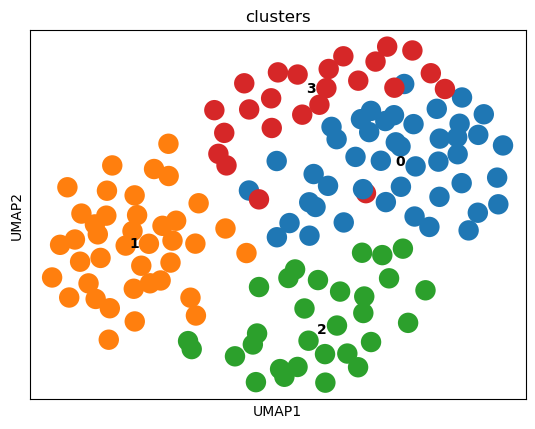

In [11]:
sc.tl.leiden(adata, key_added="clusters")
sc.pl.umap(adata, color="clusters", legend_loc="on data")


In [12]:
bdata = adata.copy()
bdata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(bdata)
sc.pp.log1p(bdata)
bdata.X = bdata.X.toarray()


In [13]:
models.download_models(
    force_update=False,
    model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)


📂 Storing models in /home/rober/.celltypist/data/models
💾 Total models to download: 2
⏩ Skipping [1/2]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/2]: Immune_All_High.pkl (file exists)


In [14]:
import mygene

mg = mygene.MyGeneInfo().querymany(
    bdata.var_names.tolist(),
    scopes="ensemblgene",
    fields="symbol",
    species="human"
)

# Build mapping
mapping = {}
for item in mg:
    if "symbol" in item:
        mapping[item["query"]] = item["symbol"]

# Apply the mapping: fallback to original name if no match
new_gene_names = [mapping.get(gene, gene) for gene in bdata.var_names]

bdata.var_names = new_gene_names

# Remove any genes that still have no symbol
bdata = bdata[:, ~pd.isnull(bdata.var_names)].copy()
print("Mapped symbol count:", len(bdata.var_names))



Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-20 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.


Mapped symbol count: 20


## 5️⃣ Automatic Cell-Type Annotation — CellTypist

We normalize raw gene counts, convert **Ensembl gene IDs → gene symbols**,  
then apply pretrained immune-cell models from CellTypist:

- **High-level (coarse)** labels → broad immune categories  
- **Detailed (fine)** labels → more specific immune cell types  

This adds biological interpretation to the clusters.


In [15]:
# Load CellTypist models
model_high = models.Model.load(model="Immune_All_High.pkl")
model_low = models.Model.load(model="Immune_All_Low.pkl")

# Run annotation (coarse)
pred_high = celltypist.annotate(bdata, model=model_high, majority_voting=True).to_adata()
adata.obs["celltypist_cell_label_coarse"] = pred_high.obs["majority_voting"]
adata.obs["celltypist_conf_score_coarse"] = pred_high.obs["conf_score"]

# Run annotation (fine)
pred_low = celltypist.annotate(bdata, model=model_low, majority_voting=True).to_adata()
adata.obs["celltypist_cell_label_fine"] = pred_low.obs["majority_voting"]
adata.obs["celltypist_conf_score_fine"] = pred_low.obs["conf_score"]



⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input dat

### Coarse Annotation

Broad cell-type assignments + model confidence per cell.

### Fine Annotation

More detailed immune cell prediction results and confidence.



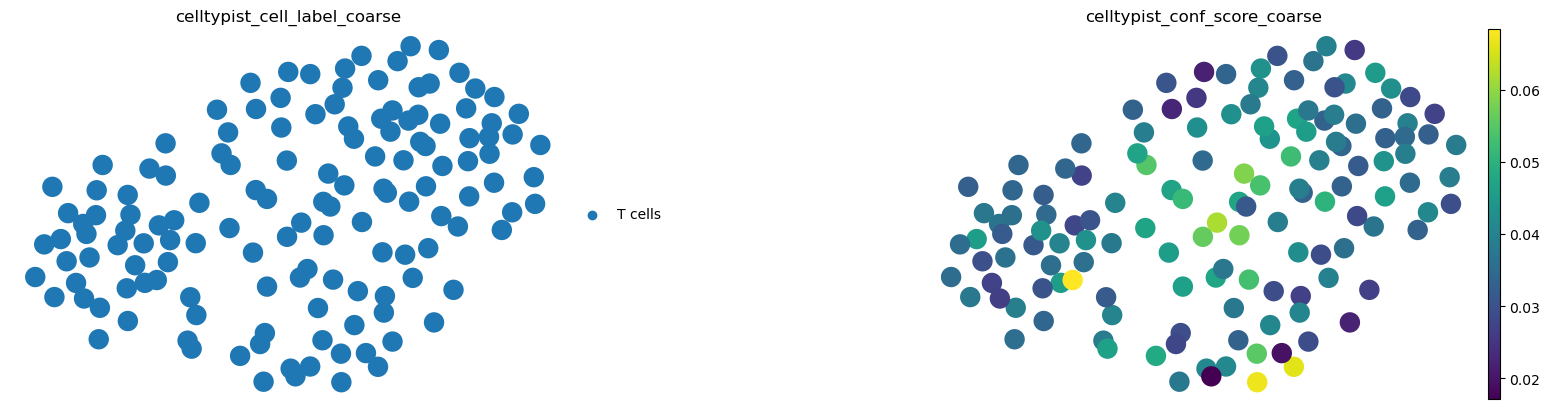

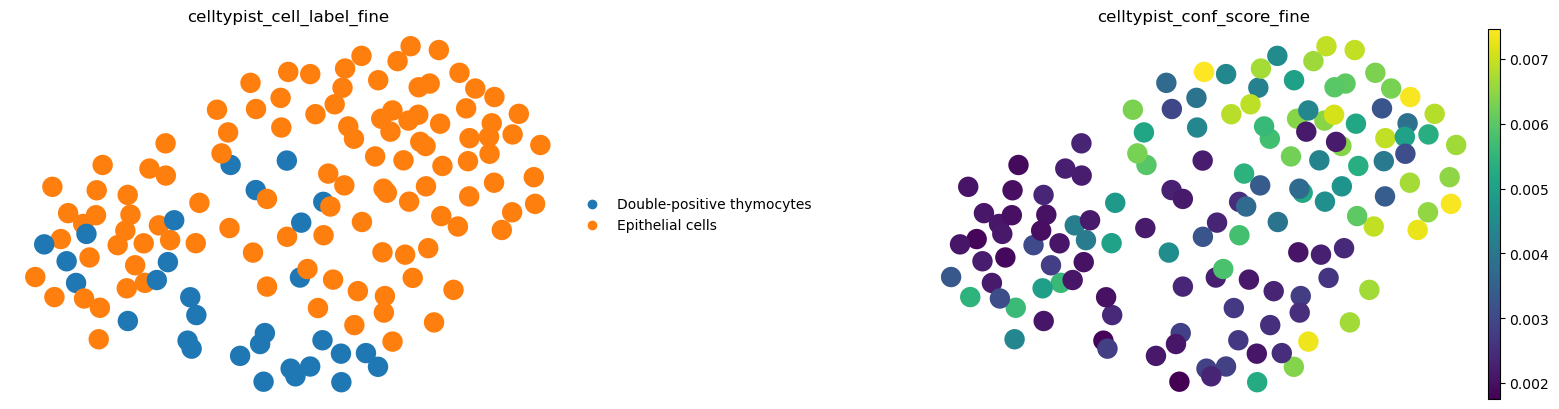

In [16]:
# Plot coarse results
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False, sort_order=False, wspace=0.5
)

# Plot fine results
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False, sort_order=False, wspace=0.5
)

